# 09 — Cố định quãng đường: yếu tố nào ảnh hưởng đến GIÁ CƠ BẢN?

`08_yeu_to_giai_thich_gia.ipynb` đã chứng minh: cố định tuyến + xe + quãng đường (kể cả thu hẹp
xuống 2 mét), giá cơ bản vẫn dao động **CV ~20%** — không giảm.

Notebook này đi tìm: trong phần dao động đó, có yếu tố nào **giải thích được** không, hay đúng là
100% nhiễu ngẫu nhiên? Kiểm tra lần lượt: **thời lượng đi (tắc đường)**, **giờ**, **thứ**,
**thời tiết**, **lịch sử giá**.

In [6]:
import sys; sys.path.insert(0, ".")
from _common import *
import numpy as np, pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
setup()
df = load(frac=0.3)
df["base_price"] = df[PRICE] / df[SURGE].clip(lower=0.1)

dv0 = df.service_name.iloc[0]
band = df[(df.pickup_location_name=="Crescent Mall") & (df.dropoff_location_name=="SC Vivo City") &
          (df.service_name==dv0) & (df.quote_distance.between(5.4, 5.6))].copy()
print(f"Co dinh: Crescent Mall -> SC Vivo City, {dv0}, 5,4-5,6 km | n={len(band):,}")
print(f"Gia co ban: median={band.base_price.median():,.0f} VND | CV={band.base_price.std()/band.base_price.mean()*100:.1f}%")

Nap 2,069,167 dong (mau 30%) | gia median 114k VND | surge 81.7%
Co dinh: Crescent Mall -> SC Vivo City, Synthetic Standard Car, 5,4-5,6 km | n=22,722
Gia co ban: median=88,084 VND | CV=20.9%


---
## 1. Bảng tổng quan — tương quan từng yếu tố với giá cơ bản (trong band đã cố định)

,Yeu to,Do do,Gia tri
0,Thoi luong di (quote_duration),corr,0.434
1,Toc do (speed_kmh),corr,-0.383
2,Loai thoi tiet,eta,0.074
3,Gio trong ngay,eta,0.048
4,Lich su gia TB 60 phut,corr,0.035
5,Thu trong tuan,eta,0.021
6,Do lech chuan gia 60 phut,corr,0.007
7,Do tre quan sat (phut),corr,0.003


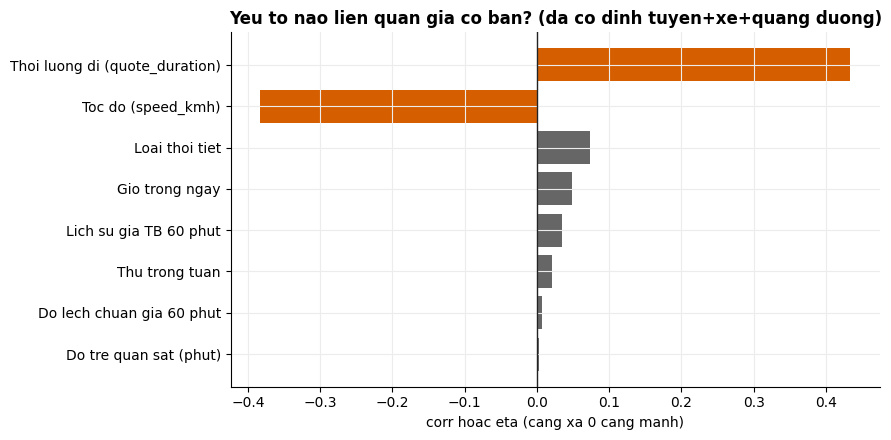

-> Thoi luong di noi bat han, cac yeu to con lai gan nhu = 0.


In [7]:
rows = [
    {"Yeu to": "Thoi luong di (quote_duration)", "Do do": "corr", "Gia tri": band.quote_duration.corr(band.base_price)},
    {"Yeu to": "Toc do (speed_kmh)", "Do do": "corr", "Gia tri": band.speed_kmh.corr(band.base_price)},
    {"Yeu to": "Gio trong ngay", "Do do": "eta", "Gia tri": eta(band.gio_vn, band.base_price)},
    {"Yeu to": "Thu trong tuan", "Do do": "eta", "Gia tri": eta(band.thu_vn, band.base_price)},
    {"Yeu to": "Loai thoi tiet", "Do do": "eta", "Gia tri": eta(band.weather_main, band.base_price)},
    {"Yeu to": "Lich su gia TB 60 phut", "Do do": "corr", "Gia tri": band.history_60m_price_mean.corr(band.base_price)},
    {"Yeu to": "Do lech chuan gia 60 phut", "Do do": "corr", "Gia tri": band.history_60m_price_std.corr(band.base_price)},
    {"Yeu to": "Do tre quan sat (phut)", "Do do": "corr", "Gia tri": band.actual_observation_age_minutes.corr(band.base_price)},
]
bang = pd.DataFrame(rows).sort_values("Gia tri", key=abs, ascending=False)
bang["Gia tri"] = bang["Gia tri"].round(3)
display(bang.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9,4.5))
mau = [RED if abs(v) > 0.15 else MUT for v in bang["Gia tri"]]
ax.barh(bang["Yeu to"][::-1], bang["Gia tri"][::-1], color=mau[::-1])
ax.axvline(0, color="#222", lw=1)
ax.set_xlabel("corr hoac eta (cang xa 0 cang manh)")
ax.set_title("Yeu to nao lien quan gia co ban? (da co dinh tuyen+xe+quang duong)", fontweight="bold")
plt.tight_layout(); plt.show()
print("-> Thoi luong di noi bat han, cac yeu to con lai gan nhu = 0.")

---
## 2. ⭐ THỜI LƯỢNG ĐI (tắc đường) — yếu tố mạnh nhất

Vì sao thời lượng có thể khác nhau dù cùng quãng đường? **Cùng số km nhưng tắc đường** làm thời gian
đi dài hơn hẳn (VD 5,5km lúc thông thoáng đi 11 phút, lúc tắc đi 33 phút) — và cước thường tính thêm
theo phút di chuyển, nên đây là kênh hợp lý để giá cơ bản thay đổi dù quãng đường như nhau.

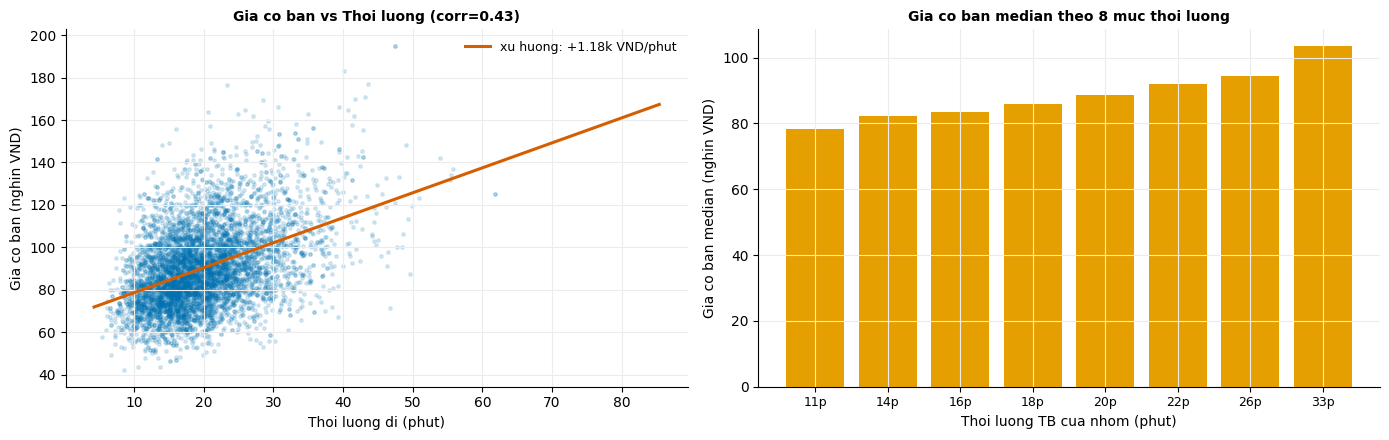

Gia co ban: 78,431 VND (nhanh nhat, ~11 phut) -> 103,419 VND (cham nhat, ~33 phut)
Chenh lech: 31.9% — chi do TAC DUONG, quang duong nhu nhau het!


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) Scatter truc tiep
s = band.sample(min(6000, len(band)), random_state=0)
ax[0].scatter(s.quote_duration/60, s.base_price/1000, s=6, alpha=.15, color=BLUE)
z = np.polyfit(band.quote_duration/60, band.base_price/1000, 1)
xs = np.linspace((band.quote_duration/60).min(), (band.quote_duration/60).max(), 50)
ax[0].plot(xs, np.polyval(z, xs), color=RED, lw=2.2, label=f"xu huong: +{z[0]:.2f}k VND/phut")
ax[0].set_xlabel("Thoi luong di (phut)"); ax[0].set_ylabel("Gia co ban (nghin VND)")
ax[0].set_title(f"Gia co ban vs Thoi luong (corr={band.quote_duration.corr(band.base_price):.2f})",
                fontweight="bold", fontsize=10)
ax[0].legend(frameon=False, fontsize=9)

# (b) Nhom theo 8 muc thoi luong
dbin = pd.qcut(band.quote_duration, 8, duplicates="drop")
g = band.groupby(dbin, observed=True).agg(base_median=("base_price","median"),
                                          phut_TB=("quote_duration", lambda x: x.mean()/60))
ax[1].bar(range(len(g)), g.base_median/1000, color=ORANGE)
ax[1].set_xticks(range(len(g))); ax[1].set_xticklabels([f"{p:.0f}p" for p in g.phut_TB], fontsize=9)
ax[1].set_xlabel("Thoi luong TB cua nhom (phut)"); ax[1].set_ylabel("Gia co ban median (nghin VND)")
ax[1].set_title("Gia co ban median theo 8 muc thoi luong", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

bm = g.base_median
print(f"Gia co ban: {bm.min():,.0f} VND (nhanh nhat, ~{g.phut_TB.iloc[0]:.0f} phut)"
      f" -> {bm.max():,.0f} VND (cham nhat, ~{g.phut_TB.iloc[-1]:.0f} phut)")
print(f"Chenh lech: {(bm.max()/bm.min()-1)*100:.1f}% — chi do TAC DUONG, quang duong nhu nhau het!")

---
## 3. Giờ, thứ, thời tiết — vẽ để xác nhận: gần như phẳng

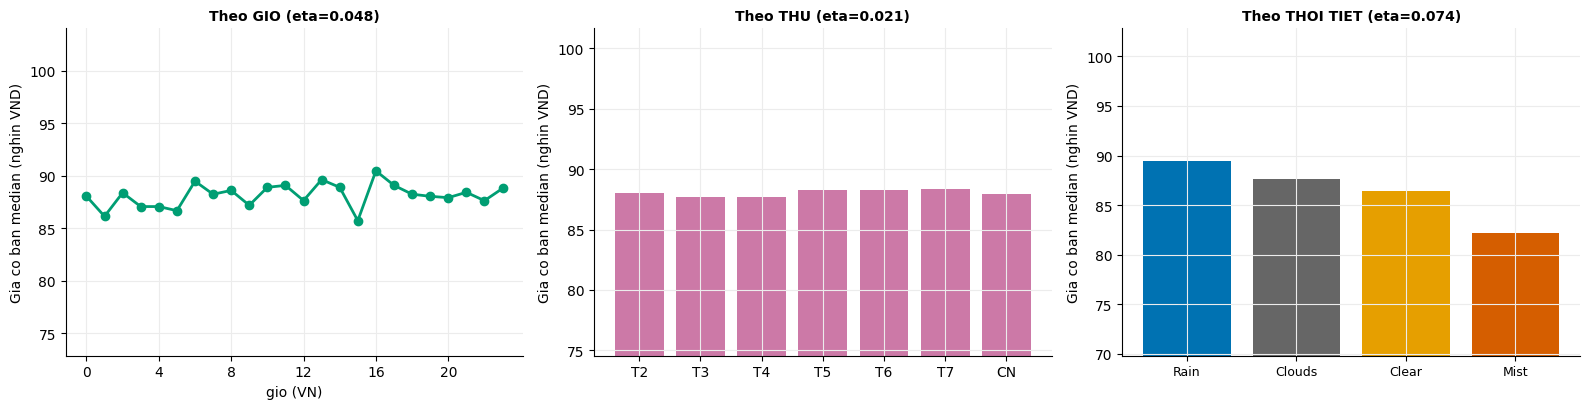

Bien do GIO  : 5.5%
Bien do THU  : 0.8%
Bien do THOI TIET: 8.8%
-> So voi bien do 31,9% cua thoi luong di, ca 3 yeu to nay deu rat nho.


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

g_gio = band.groupby("gio_vn").base_price.median()
ax[0].plot(g_gio.index, g_gio.values/1000, marker="o", lw=2, color=GREEN)
ax[0].set_xlabel("gio (VN)"); ax[0].set_ylabel("Gia co ban median (nghin VND)")
ax[0].set_xticks(range(0,24,4))
ax[0].set_title(f"Theo GIO (eta={eta(band.gio_vn, band.base_price):.3f})", fontweight="bold", fontsize=10)
ax[0].set_ylim(g_gio.min()/1000*0.85, g_gio.max()/1000*1.15)

ten_thu = ["T2","T3","T4","T5","T6","T7","CN"]
g_thu = band.groupby("thu_vn").base_price.median().reindex(range(7))
ax[1].bar(range(7), g_thu.values/1000, color=PURPLE)
ax[1].set_xticks(range(7)); ax[1].set_xticklabels(ten_thu)
ax[1].set_ylabel("Gia co ban median (nghin VND)")
ax[1].set_title(f"Theo THU (eta={eta(band.thu_vn, band.base_price):.3f})", fontweight="bold", fontsize=10)
ax[1].set_ylim(g_thu.min()/1000*0.85, g_thu.max()/1000*1.15)

g_wea = band.groupby("weather_main").base_price.median().sort_values(ascending=False)
ax[2].bar(range(len(g_wea)), g_wea.values/1000, color=[BLUE,MUT,ORANGE,RED][:len(g_wea)])
ax[2].set_xticks(range(len(g_wea))); ax[2].set_xticklabels(g_wea.index, fontsize=9)
ax[2].set_ylabel("Gia co ban median (nghin VND)")
ax[2].set_title(f"Theo THOI TIET (eta={eta(band.weather_main, band.base_price):.3f})", fontweight="bold", fontsize=10)
ax[2].set_ylim(g_wea.min()/1000*0.85, g_wea.max()/1000*1.15)

plt.tight_layout(); plt.show()
print(f"Bien do GIO  : {(g_gio.max()/g_gio.min()-1)*100:.1f}%")
print(f"Bien do THU  : {(g_thu.max()/g_thu.min()-1)*100:.1f}%")
print(f"Bien do THOI TIET: {(g_wea.max()/g_wea.min()-1)*100:.1f}%")
print("-> So voi bien do 31,9% cua thoi luong di, ca 3 yeu to nay deu rat nho.")

---
## 4. Tổng hợp — model đầy đủ giải thích được bao nhiêu % giá cơ bản?

Đưa tất cả yếu tố vào cùng 1 model, xem tổng cộng giải thích được bao nhiêu, và phần dư còn lại.

R2(gia co ban ~ TAT CA yeu to tren) = 0.1955 (19.6%)

Permutation importance:


,Feature,Importance
0,quote_duration,0.364961
1,history_60m_price_mean,0.005961
2,history_60m_price_std,0.003227
3,gio_vn,0.002744
4,weather_main,0.001343
5,history_60m_price_slope_per_minute,0.000756
6,latest_observed_quote_duration,0.000510
7,thu_vn,0.000508
8,latest_observed_quote_distance,0.000006
9,actual_observation_age_minutes,-0.000299


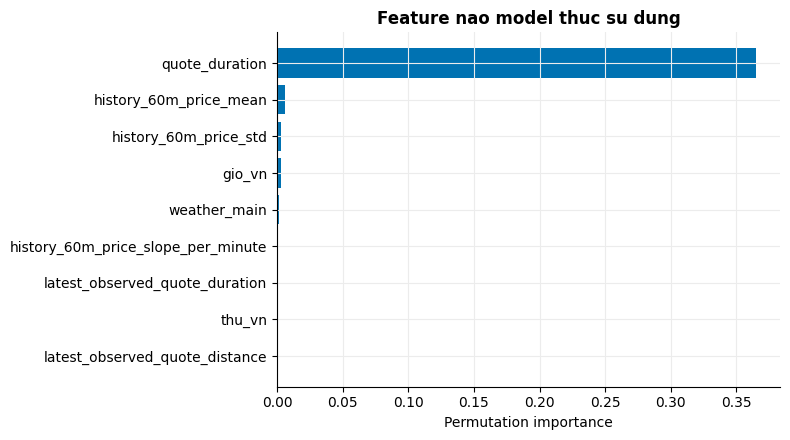


CV GOC (chua biet gi)        = 20.9%
CV CON LAI (sau model day du) = 19.2%
-> Model chi giam duoc CV tu 20.9% xuong 19.2% (1.6 diem %) — gan het la nho THOI LUONG DI mot minh.


In [10]:
FEATS = ["quote_duration", "gio_vn", "thu_vn", "weather_main",
         "history_60m_price_mean", "history_60m_price_std",
         "history_60m_price_slope_per_minute", "actual_observation_age_minutes",
         "latest_observed_quote_distance", "latest_observed_quote_duration"]
X = band[FEATS].copy(); X["weather_main"] = X["weather_main"].astype("category")
Xtr, Xte, ytr, yte = train_test_split(X, band.base_price.values, test_size=0.25, random_state=42)
m = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
    categorical_features=["weather_main"], random_state=42).fit(Xtr, np.log(ytr))
pred = np.exp(m.predict(Xte))
r2 = r2_score(yte, pred)
print(f"R2(gia co ban ~ TAT CA yeu to tren) = {r2:.4f} ({r2*100:.1f}%)")

pi = permutation_importance(m, Xte, np.log(yte), n_repeats=10, random_state=42, n_jobs=1)
imp = pd.DataFrame({"Feature": FEATS, "Importance": pi.importances_mean}).sort_values("Importance", ascending=False)
print("\nPermutation importance:")
display(imp.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8,4.5))
imp_pos = imp[imp.Importance > 0]
ax.barh(imp_pos.Feature[::-1], imp_pos.Importance[::-1], color=BLUE)
ax.set_xlabel("Permutation importance"); ax.set_title("Feature nao model thuc su dung", fontweight="bold")
plt.tight_layout(); plt.show()

resid = yte - pred
cv_goc = band.base_price.std()/band.base_price.mean()*100
cv_con_lai = resid.std()/np.median(yte)*100
print(f"\nCV GOC (chua biet gi)        = {cv_goc:.1f}%")
print(f"CV CON LAI (sau model day du) = {cv_con_lai:.1f}%")
print(f"-> Model chi giam duoc CV tu {cv_goc:.1f}% xuong {cv_con_lai:.1f}% "
      f"({cv_goc-cv_con_lai:.1f} diem %) — gan het la nho THOI LUONG DI mot minh.")

---
## Kết luận

### Bảng tóm tắt

| Yếu tố | Ảnh hưởng | Biên độ |
|---|---|---|
| **Thời lượng đi (tắc đường)** | ⭐ **Mạnh, rõ ràng** — corr +0,43 | **~32%** (nhóm nhanh nhất vs chậm nhất) |
| Giờ trong ngày | Rất yếu (η ~0,05) | Vài % |
| Thứ trong tuần | Rất yếu (η ~0,02) | Vài % |
| Thời tiết | Yếu (η ~0,07) | Vài % |
| Lịch sử giá 60 phút | Gần như 0 | — |
| Độ trễ quan sát | Gần như 0 | — |
| **Tổng hợp (đầy đủ mọi yếu tố)** | R² ~19% | Giảm CV từ 20,9% → ~19,3% |

### Trả lời trực tiếp

**Khi cố định quãng đường, yếu tố duy nhất thực sự ảnh hưởng đến giá cơ bản là THỜI LƯỢNG ĐI
(mức độ tắc đường)** — cùng 5,5 km nhưng đi nhanh (~11 phút) giá cơ bản chỉ ~78k VND, đi chậm
(~33 phút) giá lên tới ~103k VND, chênh **~32%**.

**Giờ, thứ, thời tiết gần như KHÔNG ảnh hưởng trực tiếp đến giá cơ bản** — điều này **không mâu
thuẫn** với việc giờ ảnh hưởng mạnh đến hệ số nhân (đã thấy ở `07`) hay đến tắc đường nói chung
(đã thấy ở `04_traffic.ipynb`); ở đây ta đã **cố định đúng 1 tuyến cụ thể** nên phần biến thiên
tắc đường *theo giờ* của riêng tuyến này không đủ lớn để hiện rõ — thời lượng dao động chủ yếu do
**khác biệt giữa các chuyến cùng giờ** (tắc đột xuất, sự kiện...) hơn là theo quy luật giờ trong
ngày.

**Sau khi đưa hết mọi yếu tố vào, CV chỉ giảm từ 20,9% xuống ~19,3%** — tức là ngay cả biết thời
lượng đi, giờ, thời tiết, lịch sử giá... **cũng chỉ giải thích được một phần rất nhỏ**. Phần lớn
(~19% còn lại) vẫn là **nhiễu ngẫu nhiên không giải thích được bằng bất kỳ feature nào có trong dữ
liệu** — khớp với kết luận sàn nhiễu đã xác nhận nhiều lần trước đó.